In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from src.data_loader import load_data
from src.eda_utils import *


#load data set

df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [7]:
#understaing the data seyt
df.shape
df.columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [13]:
#convert dta colomn
#print(df.columns)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [14]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M")

In [15]:
#generate summary statistics
df.describe()

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode,TransactionDate
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050,2024-09-29 14:52:22.080000
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000,2024-01-01 00:00:00
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000,2024-05-18 00:00:00
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000,2024-09-29 00:00:00
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000,2025-02-11 00:00:00
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000,2025-06-29 00:00:00
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245,NaN


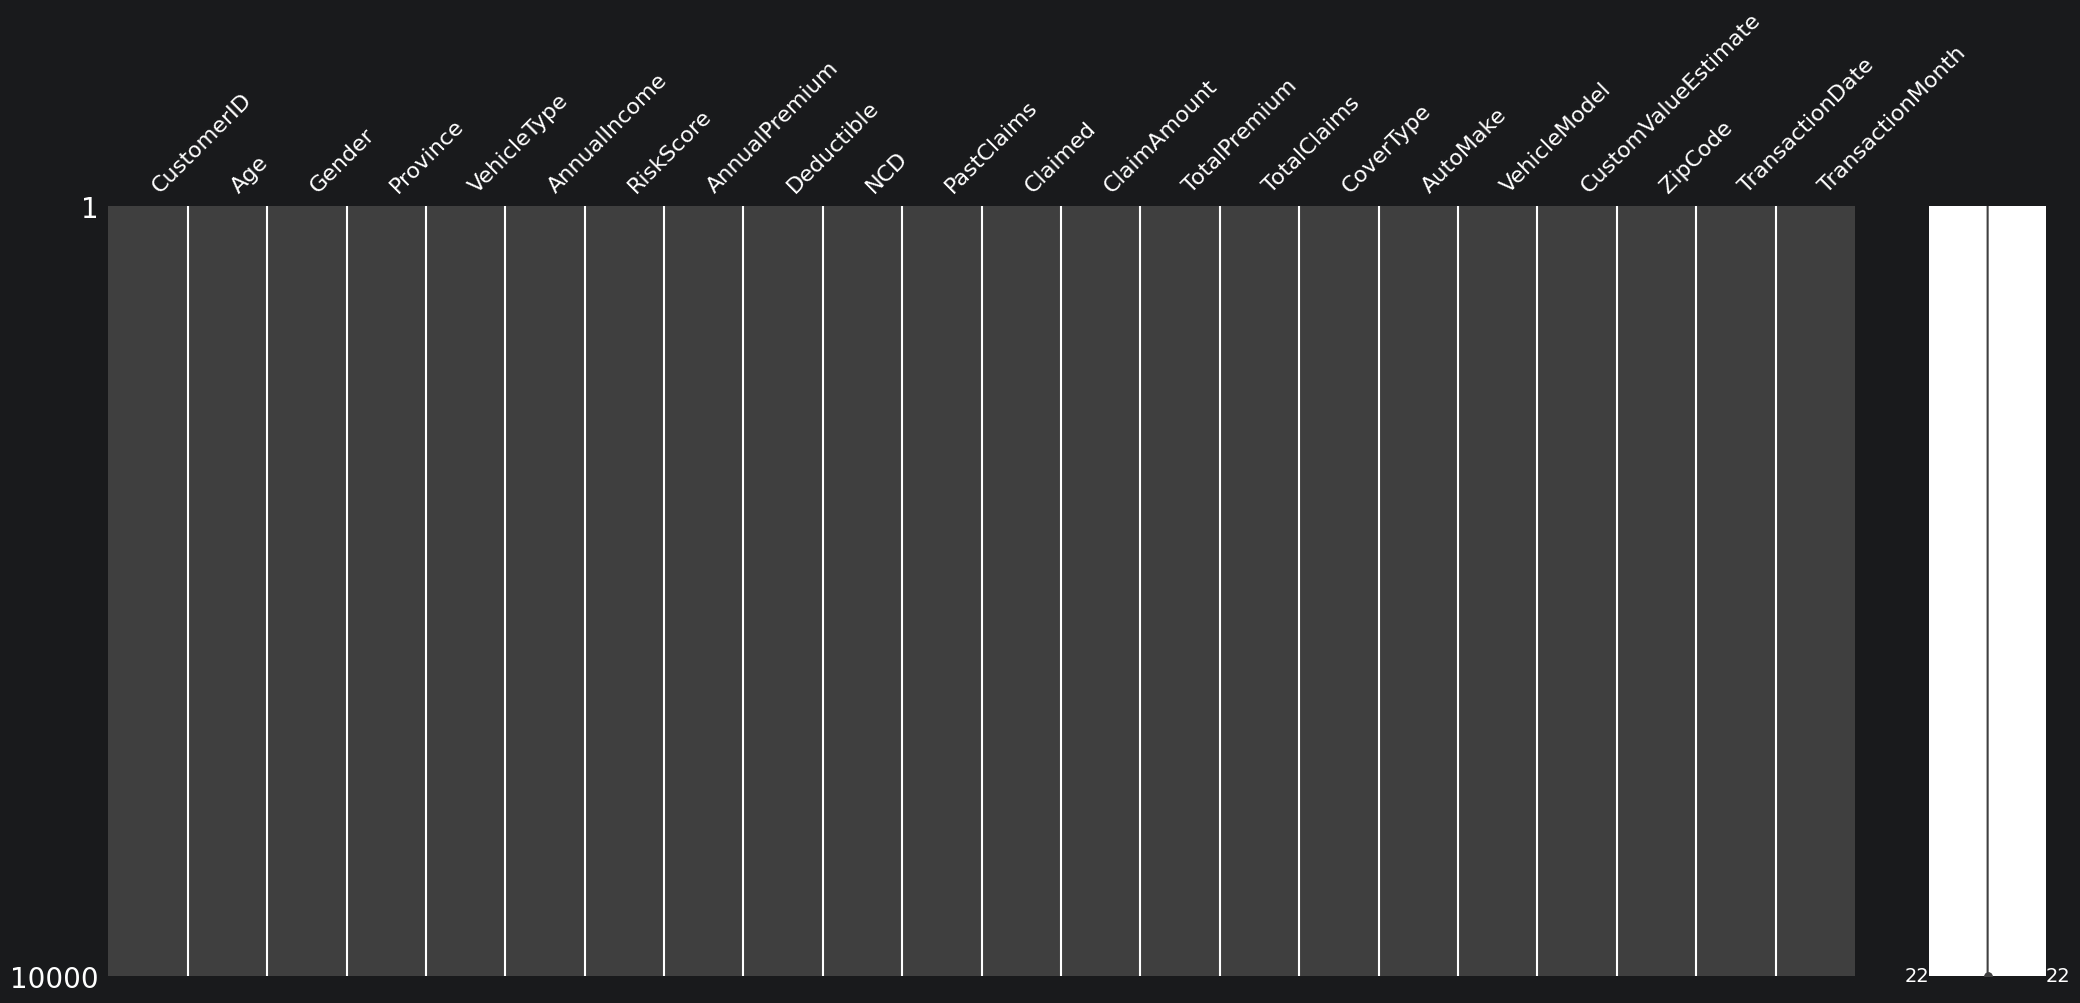

In [17]:
#assessing missing values
missing_values(df)
msno.matrix(df)
plt.show()

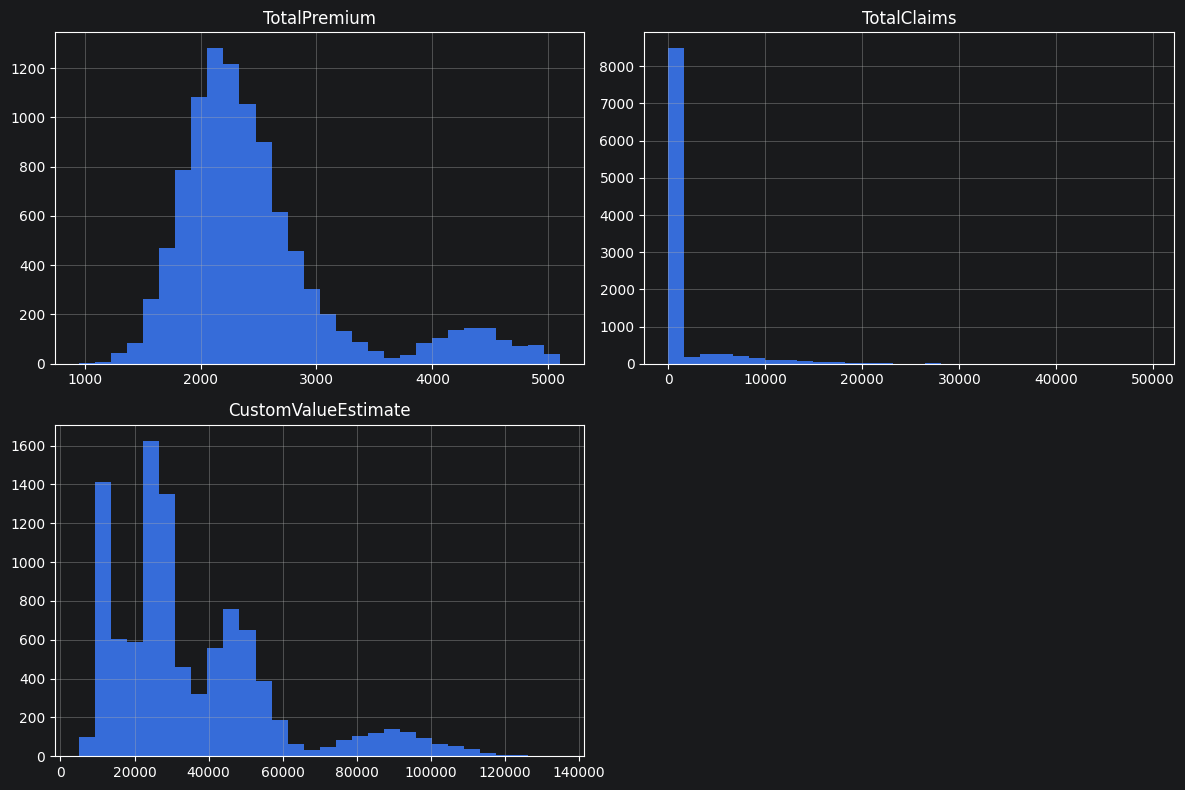

In [18]:
#universla anaysis
numeric_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate"
]

df[numeric_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()
##skewness , concentration , heavy tails

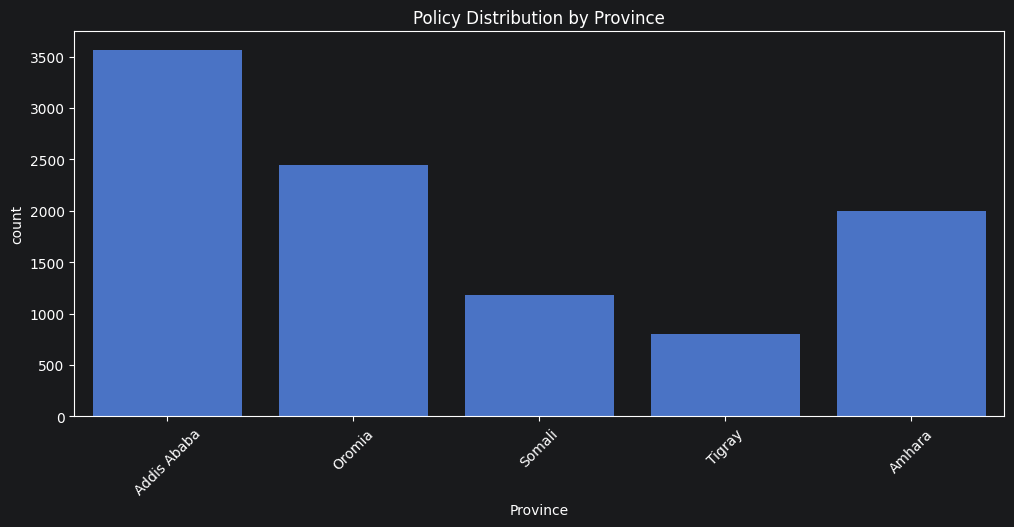

In [19]:
#Analyze Categorical Variables
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="Province"
)

plt.xticks(rotation=45)

plt.title("Policy Distribution by Province")

plt.show()
#Also analyze: Gender VehicleType CoverType

In [20]:
#outliyr

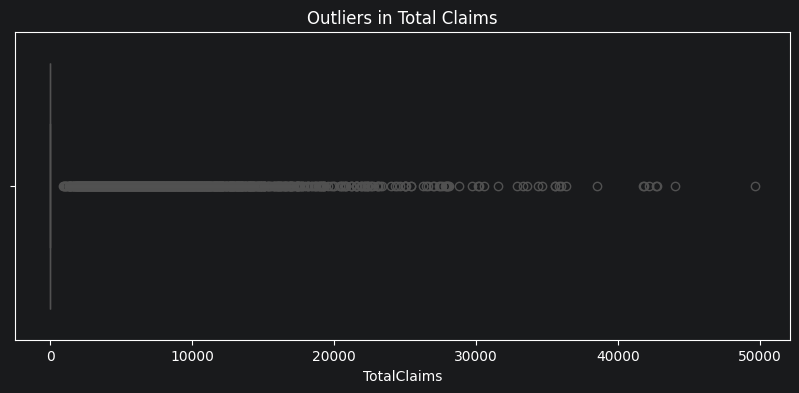

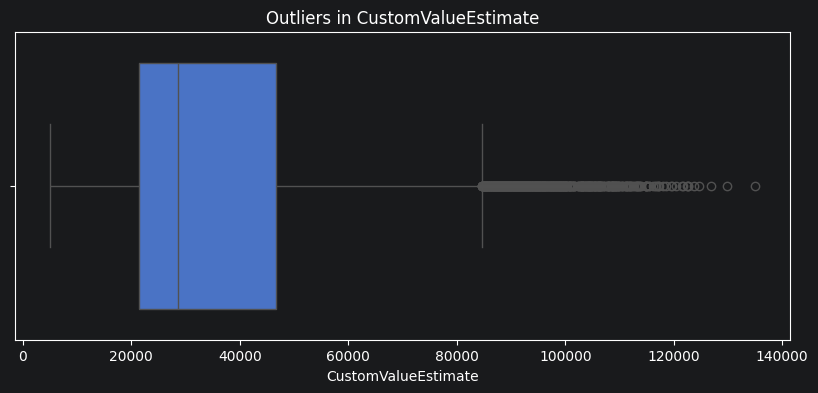

In [24]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["TotalClaims"]
)

plt.title("Outliers in Total Claims")

plt.show()
#Interpret: extreme claims premium anomalies

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["CustomValueEstimate"]
)

plt.title("Outliers in CustomValueEstimate")

plt.show()
#Interpret: extreme claims premium anomalies


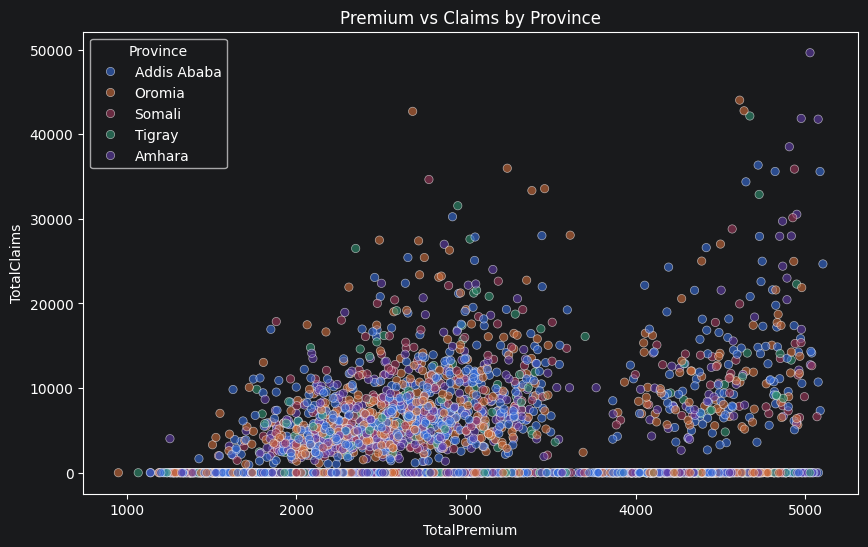

In [25]:
#bivariat analysis
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province",
    alpha=0.6
)

plt.title("Premium vs Claims by Province")

plt.show()


#Interpret: correlation clustering risky regions

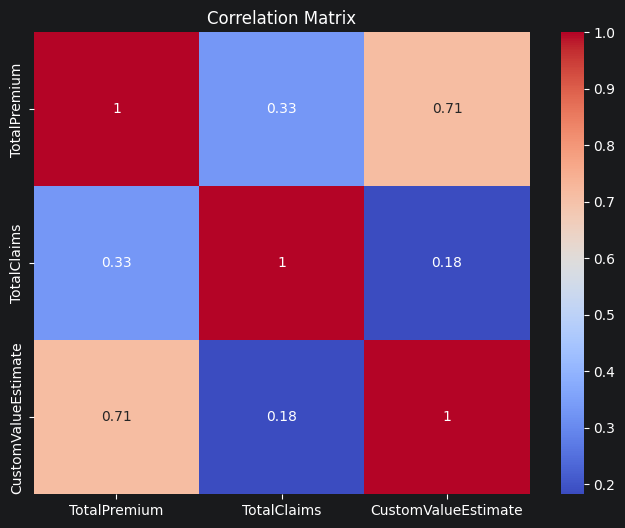

In [26]:
#correlation mattrix
corr = df[
    ["TotalPremium", "TotalClaims", "CustomValueEstimate"]
].corr()
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

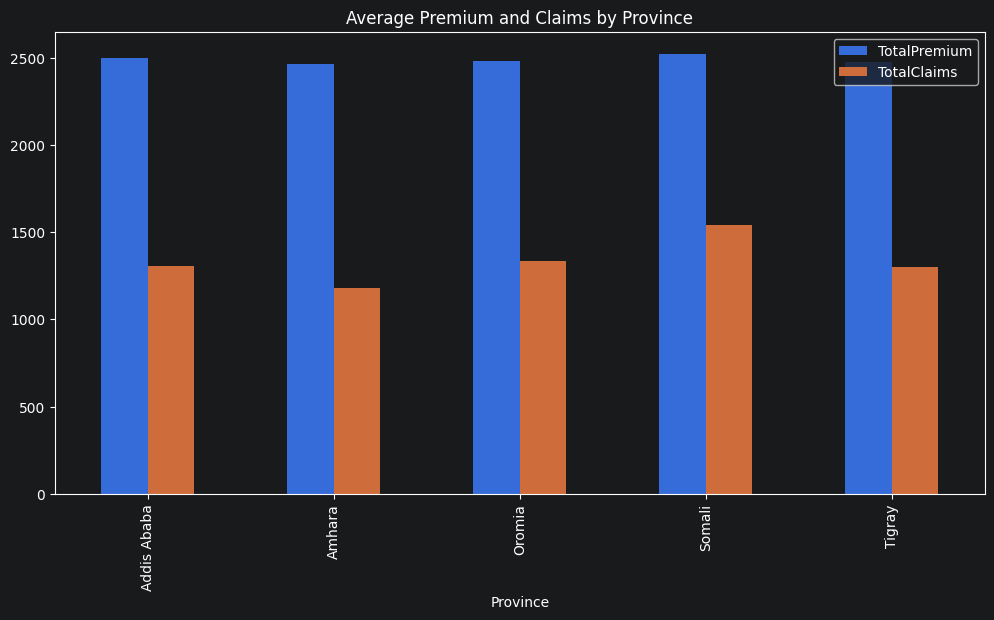

In [29]:
#geogragical treand
province_summary = (
    df.groupby("Province")[
        ["TotalPremium", "TotalClaims"]
    ]
    .mean()
)
province_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Premium and Claims by Province")

plt.show()

In [31]:
#calculating loss ratio
calculate_loss_ratio(df)
group_loss_ratio(df, "Province")

,TotalClaims,TotalPremium,LossRatio
Province,,,
Somali,1826593.0,2984984,0.611927
Oromia,3261061.0,6069663,0.537272
Tigray,1047136.0,1990692,0.526016
Addis Ababa,4653210.0,8907374,0.522400
Amhara,2353885.0,4928566,0.477600


In [33]:
group_loss_ratio(df, "Province")
group_loss_ratio(df, "VehicleType")

#Interpret: high-risk segments unprofitable groups

,TotalClaims,TotalPremium,LossRatio
VehicleType,,,
Luxury,3569207.0,4236839,0.842422
SUV,4090665.0,7256436,0.563729
Hatchback,1904235.0,4532134,0.420163
Sedan,3577778.0,8855870,0.404001


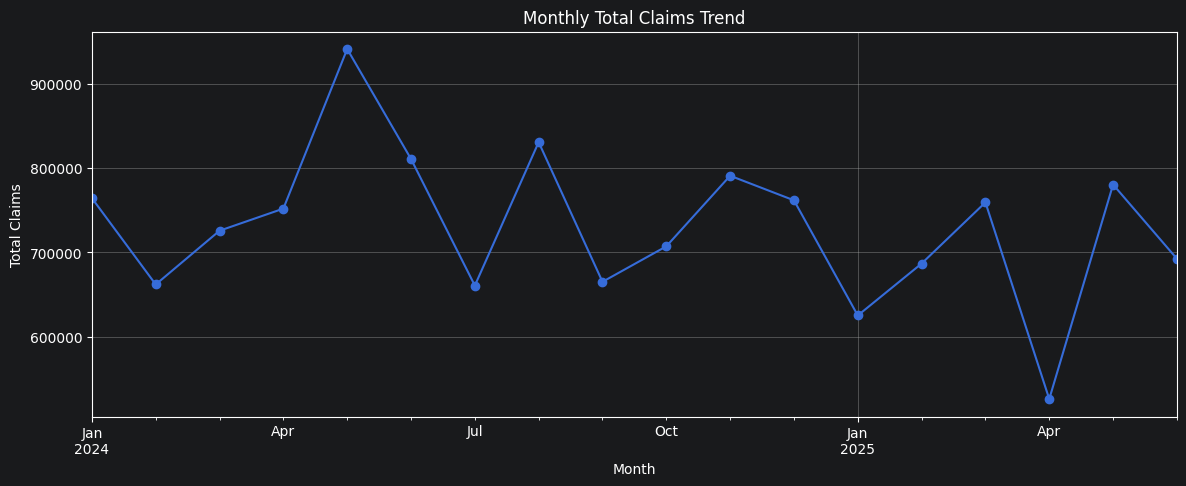

In [39]:
# Ensure datetime conversion
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# Create monthly period column
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M")

# Group by month and sum claims
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].sum()

# Plot
import matplotlib.pyplot as plt

monthly_claims.plot(figsize=(14, 5), marker="o")

plt.title("Monthly Total Claims Trend")
plt.xlabel("Month")
plt.ylabel("Total Claims")
plt.grid(True)
plt.show()

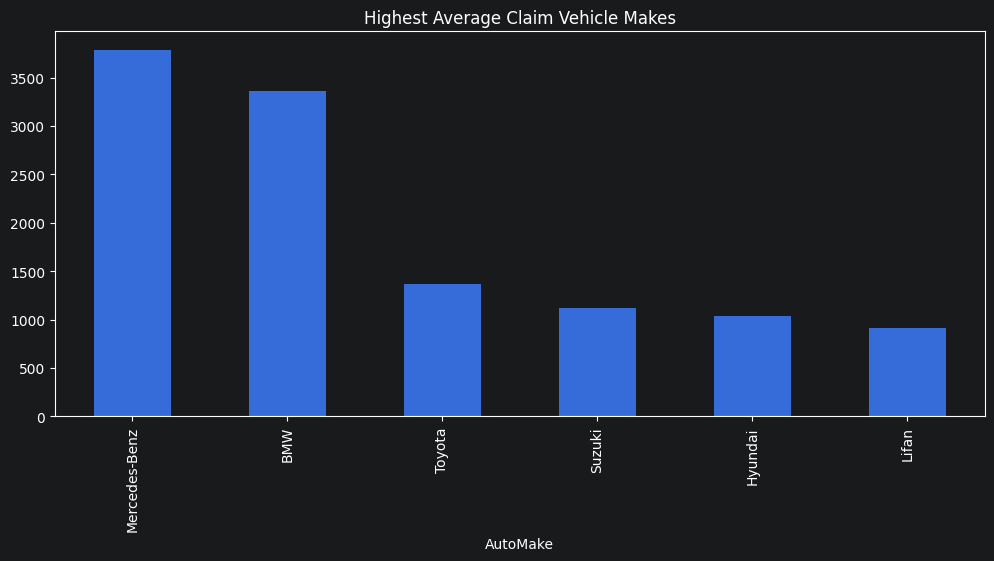

In [37]:
#Vehicle Make Analysis highest clam
vehicle_claims = (
    df.groupby("AutoMake")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
vehicle_claims.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Highest Average Claim Vehicle Makes")

plt.show()



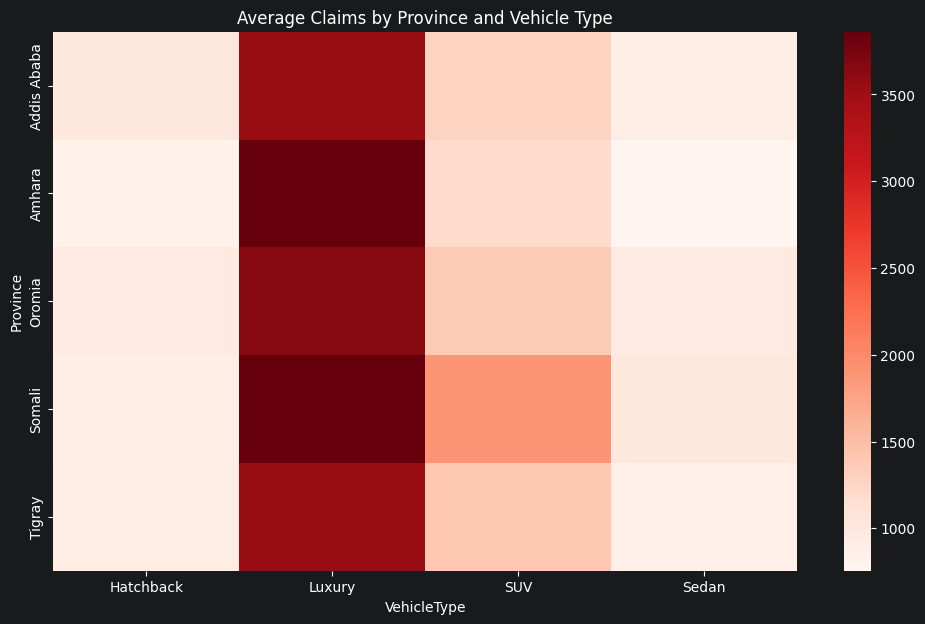

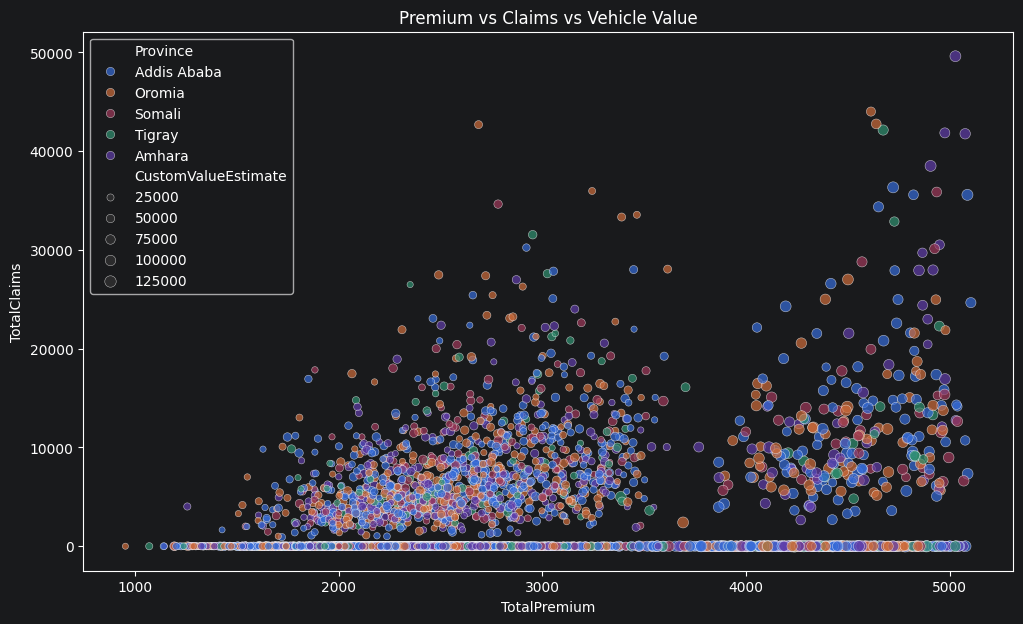

In [38]:
#Create 3 Creative Visualizations

#Province-Vehicle Heatmap
pivot = df.pivot_table(
    values="TotalClaims",
    index="Province",
    columns="VehicleType",
    aggfunc="mean"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot,
    cmap="Reds"
)

plt.title("Average Claims by Province and Vehicle Type")

plt.show()
#bubble plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    size="CustomValueEstimate",
    hue="Province",
    alpha=0.7
)

plt.title("Premium vs Claims vs Vehicle Value")

plt.show()

